In [23]:
import earthaccess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import ticker,colors
import matplotlib.style as style
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
from scipy import stats
import math
import xarray as xr
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime,date, timedelta
import datetime as dt 
import cmocean as cmoc
import cmocean.cm as cmo
from erddapy import ERDDAP
import time
import requests
from scipy import stats, odr
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2
import re
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
import os
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import ast
import matplotlib.gridspec as gridspec
import hvplot.xarray
#import holoviews as hv
import hvplot.pandas
import geoviews as gv
from bokeh.models import HoverTool
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
#import contextily as ctx
import xarray.ufuncs as xu
import matplotlib.ticker as mticker
import cblind as cblind
from datetime import date, time, datetime
import seaborn as sns

In [82]:
df = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\PACE fish-Hackweek\Hypoxia_project\Unique_PACE_matchups_NOAA_Hypoxia_2024_2025.xlsx')
df['datetime'] = pd.to_datetime(df['DATE'].astype(str) + ' ' + df['TIME'].astype(str))

#only keep where the oxygen date matches the pace date
#df['DATE'] = pd.to_datetime(df['DATE'])
#df['imageName'] = pd.to_datetime(df['imageName'], format='%Y%m%dT%H%M%S')
#only keep the rows where these two match i.e recording on the same day
#mask = df['DATE'].dt.date == df['imageName'].dt.date
#df = df[mask].copy()
#df



Text(0.5, 1.0, 'Station Locations in the Gulf of Mexico')

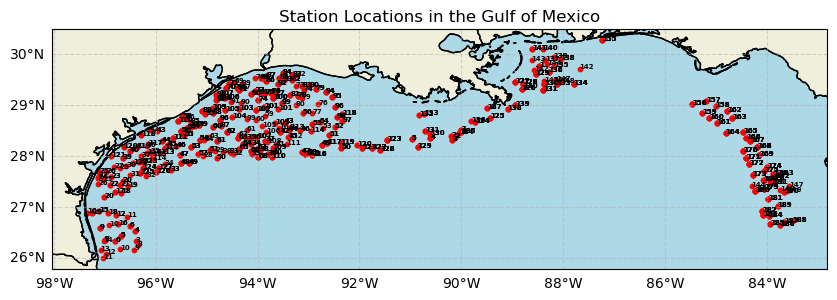

In [83]:
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.STATES)
ax.scatter(df['longitude'], df['latitude'], color='red', s=10, marker='o')
for index, row in df.iterrows():
    ax.text(row['longitude'],  row['latitude'], str(row['STATION']), transform=ccrs.PlateCarree(), fontsize=5,fontweight='bold', color='black', zorder=6) 
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax.set_title('Station Locations in the Gulf of Mexico')

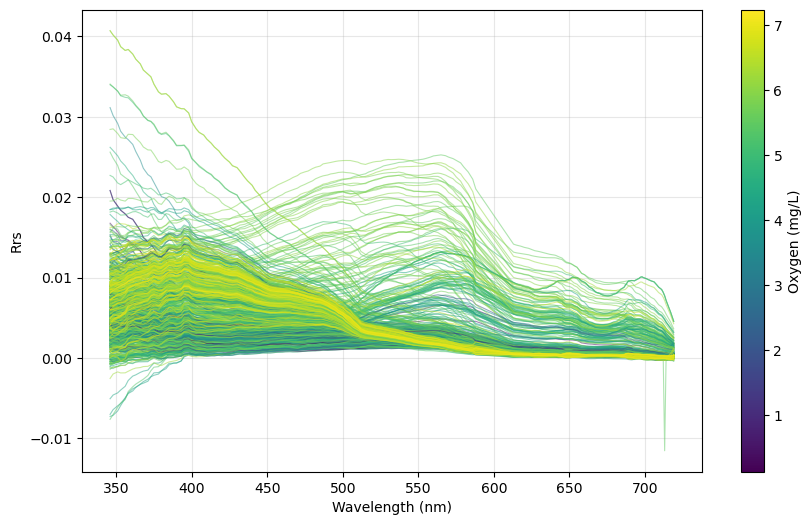

In [84]:
rrs_cols = [c for c in df.columns if 'PRrs' in c]
x_vals = [int(c.replace('PRrs', '')) for c in rrs_cols]

norm = mcolors.Normalize(vmin=df['oxygen'].min(), vmax=df['oxygen'].max())
cmap = cm.viridis 
fig, ax = plt.subplots(figsize=(10, 6))
for index, row in df.iterrows():
    color = cmap(norm(row['oxygen']))
    ax.plot(x_vals, row[rrs_cols], color=color, alpha=0.5, linewidth=0.8)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Oxygen (mg/L)')
ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Rrs')
ax.grid(True, alpha=0.3)


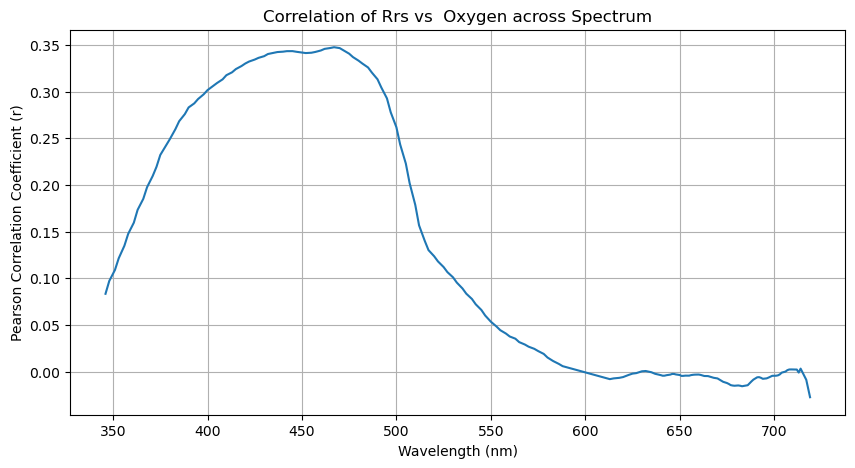

In [85]:
correlations = df[rrs_cols].corrwith(df['oxygen']) #correlation between all rrs rows and oxygen row? 
plt.figure(figsize=(10, 5))
plt.plot(x_vals, correlations)
plt.title('Correlation of Rrs vs  Oxygen across Spectrum')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Pearson Correlation Coefficient (r)')
plt.grid(True)

#peak correlation 
max_corr = correlations.abs().idxmax()
max_val = correlations[max_corr]
max_wave = max_corr.replace('PRrs', '')

#plt.annotate(f'Max Correlation at {max_wave}nm', xy=(int(max_wave), max_val), xytext=(int(max_wave)+50, max_val),arrowprops=dict(facecolor='black', shrink=0.05))





In [86]:
print('max correlation of ' + str(max_val) + ' at wavelength ' + str(max_wave))

max correlation of 0.34743991953343234 at wavelength 467


In [87]:
#actually, lets seperate by hypoxia vs not hypoxia 
df_h = df[df['oxygen']<3] #rows of hypoxia
df_nh= df[df['oxygen']>=3] #rows of no hypoxia

Text(0.5, 1.0, 'non-hypoxia points')

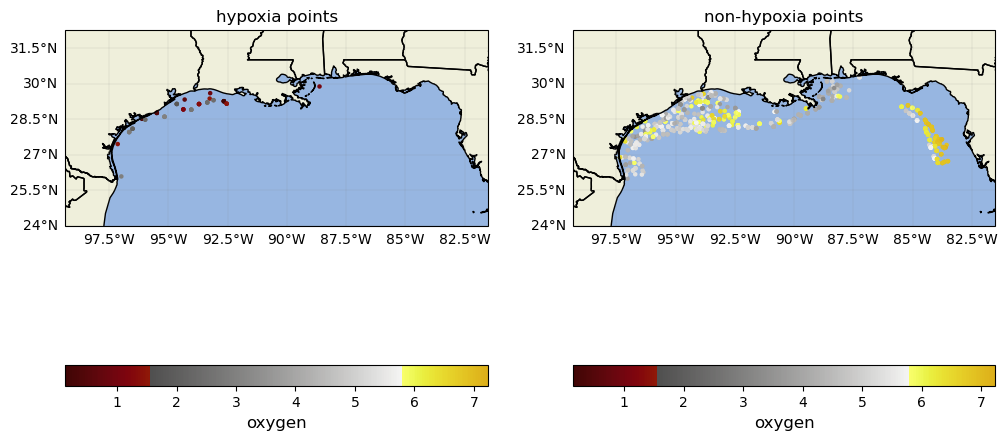

In [88]:
fig=plt.figure(figsize=(12, 12))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES)
im=axs1.scatter(df_h.longitude,df_h.latitude,c=df_h.oxygen,cmap=cmo.oxy,s=5,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs1.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs1.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
cb.set_label('oxygen',fontsize=12)
axs1.set_title("hypoxia points") 

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
axs2.add_feature(cfeature.STATES)
im=axs2.scatter(df_nh.longitude,df_nh.latitude,c=df_nh.oxygen,cmap=cmo.oxy,s=5,vmin=min(df.oxygen), vmax=max(df.oxygen))
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.5,linestyle='-',
                draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs2.set_ylim(min(df.latitude)-2,max(df.latitude)+2)
axs2.set_xlim(min(df.longitude)-2,max(df.longitude)+2)
cb=fig.colorbar(im,ax=axs2,orientation='horizontal')
cb.set_label('oxygen',fontsize=12)
axs2.set_title("non-hypoxia points") 


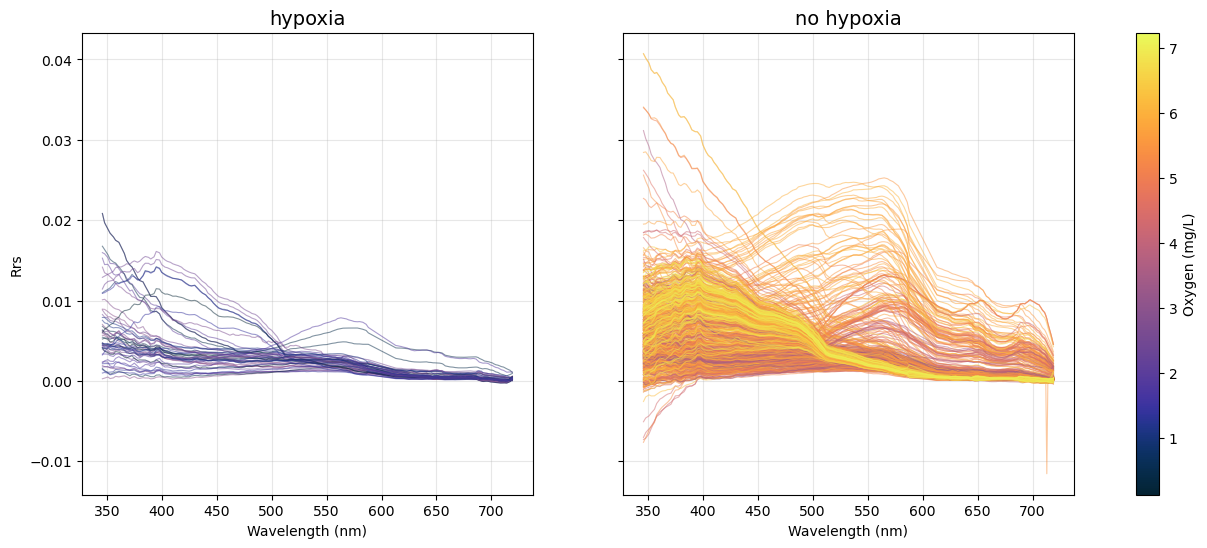

In [89]:
#need to transform columns so that wavelength is in the rows 
rrs_cols = [c for c in df.columns if 'PRrs' in c]
x_vals = [int(c.replace('PRrs', '')) for c in rrs_cols]

norm = mcolors.Normalize(vmin=df['oxygen'].min(), vmax=df['oxygen'].max())
cmap = cmo.thermal
dfs = [df_h, df_nh]
titles = ["hypoxia", "no hypoxia"] # Change these titles as needed

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, df, title in zip(axes, dfs, titles):
    for index, row in df.iterrows():
        color = cmap(norm(row['oxygen']))
        ax.plot(x_vals, row[rrs_cols], color=color, alpha=0.5, linewidth=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Wavelength (nm)')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Rrs')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), label='Oxygen (mg/L)')
plt.show()

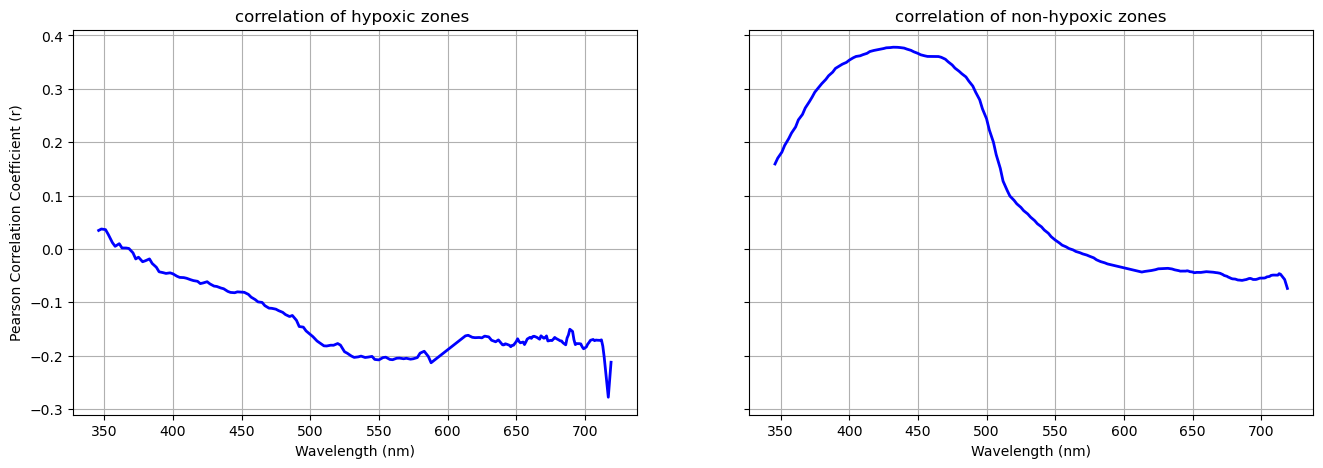

In [92]:
#measures linear correlation between two sets of data (SO PROBABLY CAN IGNORE BC ASSUMES LINIAR) 
corr1 = df_h[rrs_cols].corrwith(df_h['oxygen']) #correlation between all rrs rows and oxygen row? 
corr2 = df_nh[rrs_cols].corrwith(df_nh['oxygen']) #correlation between all rrs rows and oxygen row? 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
ax1.plot(x_vals, corr1, color='blue', linewidth=2)
ax1.set_title('correlation of hypoxic zones ')
ax1.set_ylabel('Pearson Correlation Coefficient (r)')
ax1.set_xlabel('Wavelength (nm)')
ax1.grid(True)

ax2.plot(x_vals, corr2, color='blue', linewidth=2) # Different color to distinguish
ax2.set_title('correlation of non-hypoxic zones')
ax2.set_xlabel('Wavelength (nm)')
ax2.grid(True)


In [93]:
#peak correlation 
max_corr = corr1.abs().idxmax()
max_val = corr1[max_corr]
max_wave = max_corr.replace('PRrs', '')
print('for hypoxic: max correlation of ' + str(max_val) + ' at wavelength ' + str(max_wave))

max_corr = corr2.abs().idxmax()
max_val = corr2[max_corr]
max_wave = max_corr.replace('PRrs', '')
print('for non- hypoxic: max correlation of ' + str(max_val) + ' at wavelength ' + str(max_wave))

for hypoxic: max correlation of -0.2780410201510476 at wavelength 717
for non- hypoxic: max correlation of 0.37798959304759727 at wavelength 432
